# Unsolved Networks Analysis

In [2]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

### Choose the networks to analyse

In [3]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_scenario2040-ext-TP_"

### Set paths

In [4]:
# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/resources/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/resources/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/resources/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


## Check

### Capacity

In [5]:
component_specs = [("generators", "p_nom"), ("storage_units", "p_nom"), ("links", "p_nom")]

for network_name, network in networks.items():
    carrier_capacity = pd.Series(dtype=float)

    for component_name, capacity_column in component_specs:
        component = getattr(network, component_name, None)
        if component is None or component.empty or "carrier" not in component.columns or capacity_column not in component.columns:
            continue
        carrier_capacity = carrier_capacity.add(component.groupby("carrier")[capacity_column].sum(), fill_value=0)

    carrier_capacity = carrier_capacity.sort_values(ascending=False)
    print(f"\n{network.name} installed capacity by carrier [MW]")
    if carrier_capacity.empty:
        print("  No carrier capacity found.")
    else:
        print(carrier_capacity.to_string(float_format=lambda value: f"{value:.2f}"))


Windy installed capacity by carrier [MW]
carrier
solar                367000.00
onwind               209000.00
offwind-ac            66000.00
CCGT                  29000.00
PHS                    7361.72
OCGT                   6112.74
ror                    6000.00
waste                  3127.66
biomass                3000.00
hydro                   402.24
geothermal               26.90
H2 Electrolysis           0.00
DC                        0.00
H2 Fuel Cell              0.00
lignite                   0.00
battery charger           0.00
battery discharger        0.00
coal                      0.00
oil                       0.00
offwind-float             0.00
offwind-dc                0.00
solar-hsat                0.00

Not Windy installed capacity by carrier [MW]
carrier
solar                367000.00
onwind               209000.00
offwind-ac            66000.00
CCGT                  29000.00
PHS                    7361.72
OCGT                   6112.74
ror                    6000.

### Coal price

In [6]:
carrier_name = "coal"

for network in networks.values():
    if hasattr(network, "generators"):
        g = network.generators
        if "carrier" in g.columns and "marginal_cost" in g.columns:
            mask = g["carrier"] == carrier_name
            if mask.any():
                original_costs = g.loc[mask, "marginal_cost"].copy()
                print(f"Marginal costs for '{carrier_name}' generators from {original_costs.iloc[0]:.2f}")
            else:
                print(f"No '{carrier_name}' generators found to modify costs.")

Marginal costs for 'coal' generators from 20.59
Marginal costs for 'coal' generators from 20.59
Marginal costs for 'coal' generators from 20.59


### Components

In [7]:
print("\n=== Network Statistics ===")
for n in networks.values():
    print(f"\nNetwork: {n.name}")
    for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
        if hasattr(n, dfname):
            print(f"  {dfname}: {len(getattr(n, dfname))}")


=== Network Statistics ===

Network: Windy
  buses: 1350
  lines: 642
  generators: 3305
  loads: 450
  links: 1818
  storage_units: 61
  stores: 900

Network: Not Windy
  buses: 1350
  lines: 642
  generators: 3305
  loads: 450
  links: 1818
  storage_units: 61
  stores: 900

Network: Wind Variability
  buses: 1350
  lines: 642
  generators: 3305
  loads: 450
  links: 1818
  storage_units: 61
  stores: 900


### Statistics

In [8]:
print("\n=== Network Statistics ===")
for n in networks.values():
    print(f"\nNetwork: {n.name}")
    print(n.statistics().to_string())
    print("\n")

print("\n=== Analysis Complete ===")


=== Network Statistics ===

Network: Windy
                                  Optimal Capacity  Installed Capacity  Supply  Withdrawal  Energy Balance Transmission Capacity Factor  Curtailment  Capital Expenditure  Operational Expenditure  Revenue  Market Value
Generator   Combined-Cycle Gas                 0.0        2.900000e+04     0.0         0.0             0.0          0.0             0.0          0.0                  0.0                      0.0      0.0           0.0
            Offshore Wind (AC)                 0.0        6.600000e+04     0.0         0.0             0.0          0.0             0.0          0.0                  0.0                      0.0      0.0           0.0
            Onshore Wind                       0.0        2.090000e+05     0.0         0.0             0.0          0.0             0.0          0.0                  0.0                      0.0      0.0           0.0
            Open-Cycle Gas                     0.0        6.112744e+03     0.0      

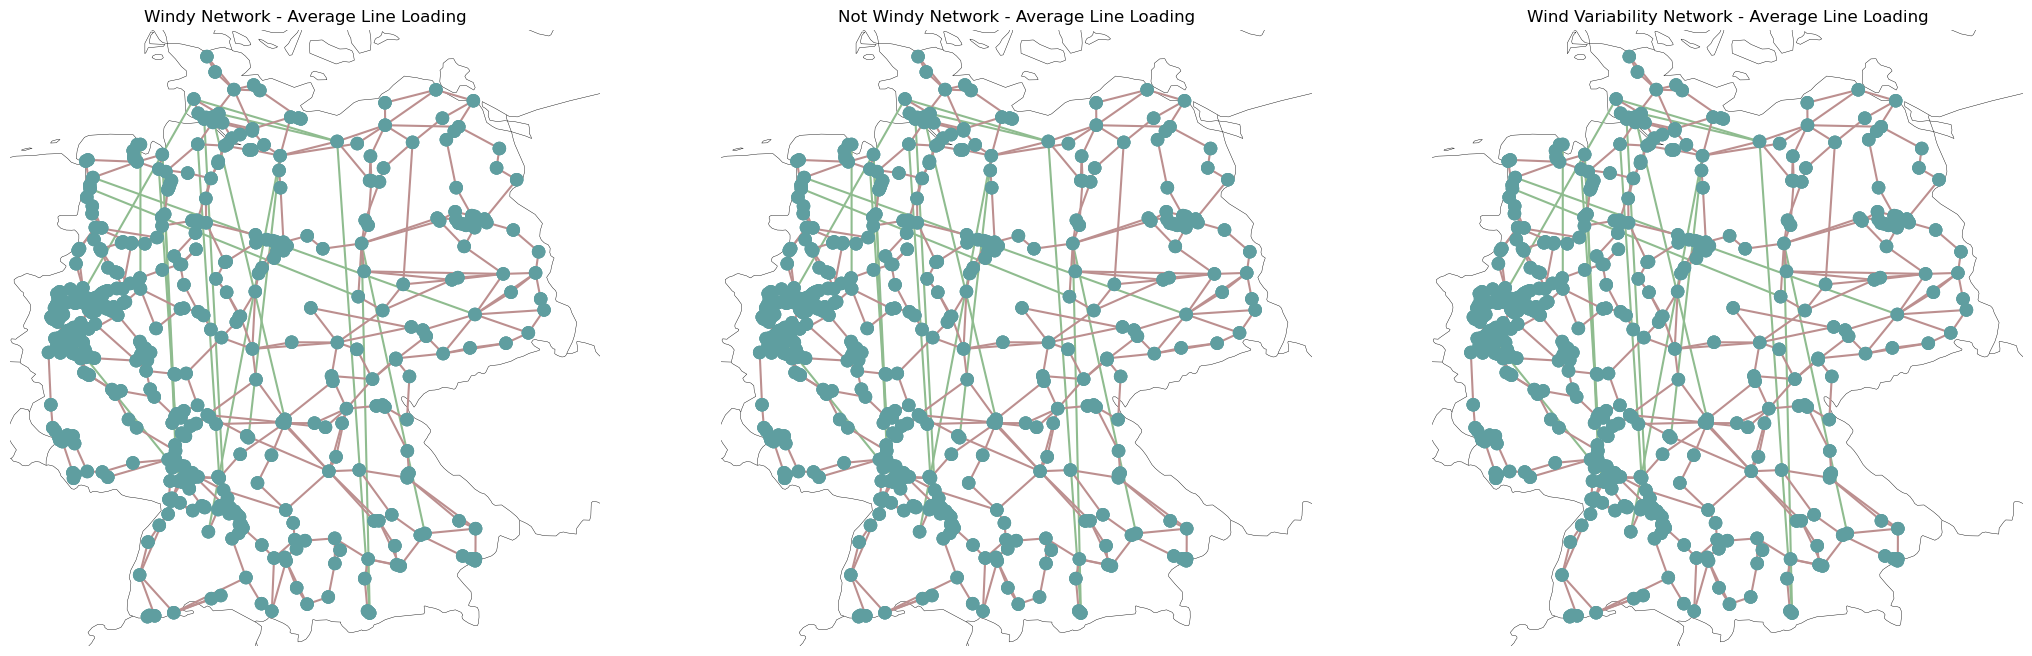

In [9]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01,
    )

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    plot_network_congestion(n, axes[i], n.name + " Network - Average Line Loading")
    i += 1


In [10]:
links_now = n.links[(n.links.build_year < 2025)]
len(links_now)

1801

In [11]:
links_future = n.links[(n.links.build_year > 2025)]
len(links_future)

16

In [15]:
links_future

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,ramp_limit_shut_down,p_nom_opt,voltage,geometry,under_construction,underground,dc,underwater_fraction,project_status,tags
name,,,,,,,,,,,,,,,,,,,,,
TYNDP2020_1_NEP_DC3,DE0 264,DE0 3,,DC,1.0,True,2028,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (9.1395423 53.8972549, 9.1258701 49...",1.0,1.0,NaN,0.01,confirmed,"""url""=>""https://tyndp2020-project-platform.azu..."
TYNDP2020_2_NEP_DC4,DE0 388,DE0 299,,DC,1.0,True,2028,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (9.3741366 53.9233519, 10.1810033 5...",1.0,1.0,NaN,0.02,confirmed,"""url""=>""https://tyndp2020-project-platform.azu..."
DC21,DE0 232,DE0 79,,DC,1.0,True,2032,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (8.106301 53.5278793, 8.0787633 51....",1.0,1.0,NaN,0.03,confirmed,"{""url"":""https://data.netzausbau.de/2037-2023/N..."
DC25,DE0 111,DE0 292,,DC,1.0,True,2032,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (9.0929015 54.1948456, 7.0528322 51...",1.0,1.0,NaN,0.07,confirmed,"{""url"":""https://data.netzausbau.de/2037-2023/N..."
DC31,DE0 111,DE0 138,,DC,1.0,True,2032,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (9.08263 54.1506435, 11.3010418 53....",1.0,1.0,NaN,0.00,confirmed,"{""url"":""https://data.netzausbau.de/2037-2023/N..."
DC32,DE0 328,DE0 138,,DC,1.0,True,2034,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (9.4944931 54.0409041, 11.3010418 5...",1.0,1.0,NaN,0.00,confirmed,"{""url"":""https://data.netzausbau.de/2037-2023/N..."
DC34,DE0 14,DE0 324,,DC,1.0,True,2033,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (8.4209977 53.3427799, 8.4747076 49...",1.0,1.0,NaN,0.00,confirmed,"{""url"":""https://data.netzausbau.de/2037-2023/N..."
DC35,DE0 14,DE0 345,,DC,1.0,True,2035,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (8.4209977 53.3427799, 8.4320722 50...",1.0,1.0,NaN,0.00,confirmed,"{""url"":""https://data.netzausbau.de/2037-2023/N..."
DC40,DE0 175,DE0 75,,DC,1.0,True,2037,inf,0.0,0.0,...,NaN,0.0,NaN,"LINESTRING (7.4360347 53.2625382, 13.4054041 5...",1.0,1.0,NaN,0.00,confirmed,"{""url"":""https://data.netzausbau.de/2037-2023/N..."


In [17]:
links_future[['carrier','build_year', 'project_status']]

,carrier,build_year,project_status
name,,,
TYNDP2020_1_NEP_DC3,DC,2028,confirmed
TYNDP2020_2_NEP_DC4,DC,2028,confirmed
DC21,DC,2032,confirmed
DC25,DC,2032,confirmed
DC31,DC,2032,confirmed
DC32,DC,2034,confirmed
DC34,DC,2033,confirmed
DC35,DC,2035,confirmed
DC40,DC,2037,confirmed


In [13]:
links_by_groups = links_now.groupby("carrier").sum()
links_by_groups

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,ramp_limit_shut_down,p_nom_opt,voltage,geometry,under_construction,underground,dc,underwater_fraction,project_status,tags
carrier,,,,,,,,,,,,,,,,,,,,,
DC,DE0 375,DE0 323,,1.000000,1,2024,inf,0.0,0.0,1,...,0.0,0.0,0.0,"LINESTRING (6.58493 51.245584, 8.478699 49.283...",1.0,0.0,0.0,0.0,in_permitting,"""url""=>""https://tyndp2020-project-platform.azu..."
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,,
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,,
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,,
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0.0,0.0,0.0,,0.0,0.0,0.0,0.0,,
